<a href="https://colab.research.google.com/github/Ruhul73/Kidney-Disease-/blob/interfce/kidney_complete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🩺 Kidney CT Scan Disease Classifier
**Classes:** Normal | Cyst | Stone | Tumor

Sab cells upar se neeche run karo. Last cell mein web interface launch hoga.

In [1]:
# Cell 1: Install packages
!pip install gradio kagglehub tensorflow -q

In [2]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
# Removed: matplotlib.use('Agg')
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
import kagglehub
print('TensorFlow version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Cell 3: Download Dataset
path = kagglehub.dataset_download('nazmul0087/ct-kidney-dataset-normal-cyst-tumor-and-stone')
print('Dataset path:', path)

# Find correct data directory
DATA_DIR = None
for root, dirs, files in os.walk(path):
    if any(d in ['Cyst', 'Normal', 'Stone', 'Tumor'] for d in dirs):
        DATA_DIR = root
        break

if DATA_DIR is None:
    DATA_DIR = path

print('DATA_DIR:', DATA_DIR)
print('Contents:', os.listdir(DATA_DIR))

Using Colab cache for faster access to the 'ct-kidney-dataset-normal-cyst-tumor-and-stone' dataset.
Dataset path: /kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone
DATA_DIR: /kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone
Contents: ['Cyst', 'Tumor', 'Stone', 'Normal']


In [4]:
# Cell 4: Load & Prepare Dataset
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset='training',
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset='validation',
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

CLASS_NAMES = train_ds.class_names
NUM_CLASSES = len(CLASS_NAMES)
print('Classes:', CLASS_NAMES)
print('Num classes:', NUM_CLASSES)

Found 12446 files belonging to 4 classes.
Using 9957 files for training.
Found 12446 files belonging to 4 classes.
Using 2489 files for validation.
Classes: ['Cyst', 'Normal', 'Stone', 'Tumor']
Num classes: 4


In [5]:
# Cell 5: Class weights (handle imbalance)
from collections import Counter

all_labels = []
for _, labels in train_ds.unbatch():
    all_labels.append(labels.numpy())

counter = Counter(all_labels)
total = sum(counter.values())
class_weights = {cls: total / (NUM_CLASSES * count) for cls, count in counter.items()}
print('Class weights:', class_weights)

Class weights: {np.int32(3): 1.3737582781456954, np.int32(0): 0.8375672947510094, np.int32(2): 2.2691431175934365, np.int32(1): 0.6107090284592738}


In [6]:
# Cell 6: Data Augmentation & Optimization
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=AUTOTUNE
).cache().prefetch(buffer_size=AUTOTUNE)

val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
print('Datasets ready!')

Datasets ready!


In [7]:
# Cell 7: Build Model (ResNet50V2)
base_model = tf.keras.applications.ResNet50V2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = tf.keras.applications.resnet_v2.preprocess_input(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)
model.compile(
    optimizer=tf.keras.optimizers.Adam(0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,090,372 (91.90 MB)

 Trainable params: 525,572 (2.00 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

In [8]:
# Cell 8: Train Model
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3,
    class_weight=class_weights,
    callbacks=callbacks
)
print('Training complete!')

Epoch 1/3
312/312 ━━━━━━━━━━━━━━━━━━━━ 157s 449ms/step - accuracy: 0.7444 - loss: 0.6551 - val_accuracy: 0.7847 - val_loss: 0.5222 - learning_rate: 5.0000e-04
Epoch 2/3
312/312 ━━━━━━━━━━━━━━━━━━━━ 31s 101ms/step - accuracy: 0.8815 - loss: 0.3224 - val_accuracy: 0.8546 - val_loss: 0.3585 - learning_rate: 5.0000e-04
Epoch 3/3
312/312 ━━━━━━━━━━━━━━━━━━━━ 30s 95ms/step - accuracy: 0.9226 - loss: 0.2192 - val_accuracy: 0.8638 - val_loss: 0.3327 - learning_rate: 5.0000e-04
Training complete!


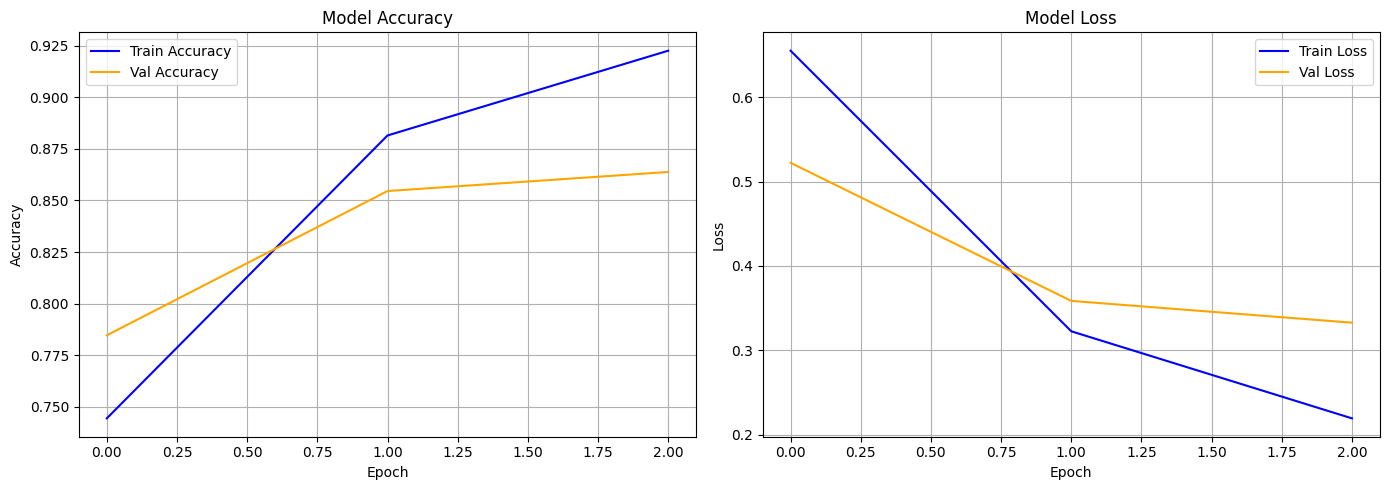

In [9]:
# Cell 9: Plot Training History
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'], label='Train Loss', color='blue')
ax2.plot(history.history['val_loss'], label='Val Loss', color='orange')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [10]:
# Cell 10: Evaluate Model
loss, accuracy = model.evaluate(val_ds)
print(f'Validation Loss: {loss:.4f}')
print(f'Validation Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)')

# Classification Report
y_true, y_pred = [], []
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

78/78 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - accuracy: 0.8638 - loss: 0.3327
Validation Loss: 0.3327
Validation Accuracy: 0.8638 (86.38%)

Classification Report:
              precision    recall  f1-score   support

        Cyst       0.96      0.80      0.87       737
      Normal       0.93      0.93      0.93      1001
       Stone       0.54      0.96      0.69       280
       Tumor       0.98      0.78      0.87       471

    accuracy                           0.86      2489
   macro avg       0.85      0.87      0.84      2489
weighted avg       0.90      0.86      0.87      2489



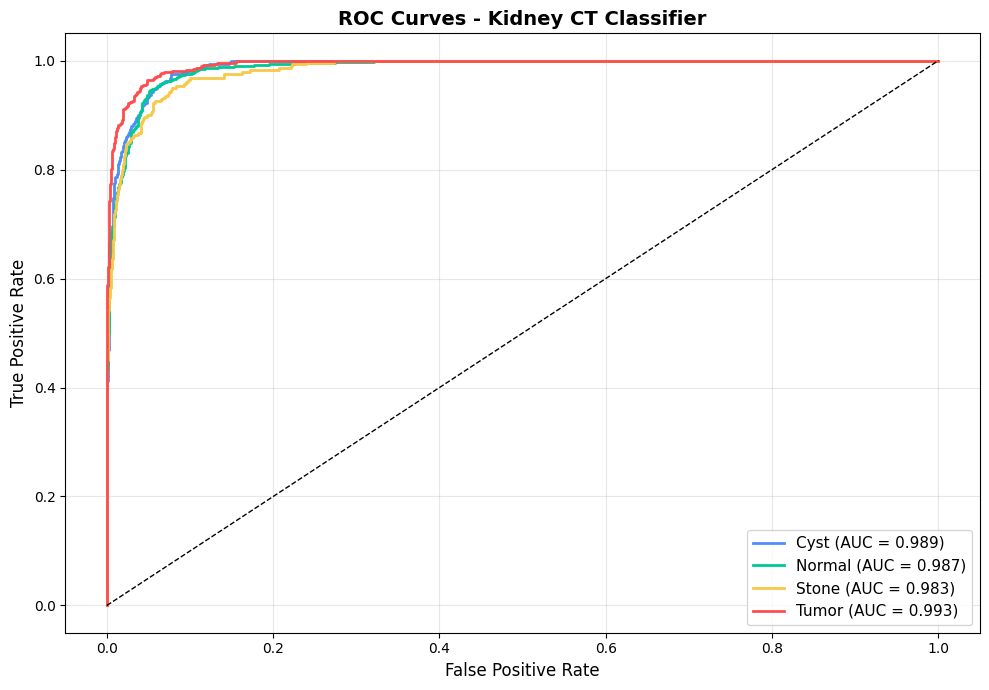

In [11]:
# Cell 11: ROC-AUC Curves
y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
y_score = []
for images, _ in val_ds:
    y_score.extend(model.predict(images, verbose=0))
y_score = np.array(y_score)

colors = ['#4f8ef7', '#00c896', '#f7c948', '#ff4d4d']
plt.figure(figsize=(10, 7))
for i, (cls, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    auc = roc_auc_score(y_true_bin[:, i], y_score[:, i])
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{cls} (AUC = {auc:.3f})')

plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Kidney CT Classifier', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# Cell 12: Save Model
import os
save_path = '/content/kidney_model.keras'
model.save(save_path)
print(f'Model saved to: {save_path}')

Model saved to: /content/kidney_model.keras


In [13]:
# Cell 13: Launch Web Interface (Gradio)
import gradio as gr
import numpy as np
import tensorflow as tf
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import io
from PIL import Image

# ─── Load Model ───────────────────────────────────────────────────────────────
try:
    kidney_model = model  # already trained above
    print('Using already-trained model.')
except NameError:
    kidney_model = tf.keras.models.load_model('/content/kidney_model.keras')
    kidney_model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    print('Model loaded from disk.')

# ─── Class Info ───────────────────────────────────────────────────────────────
CLASSES = ['Cyst', 'Normal', 'Stone', 'Tumor']

CLASS_INFO = {
    'Normal': {
        'emoji': '✅', 'color': '#00c896',
        'desc': 'No abnormality detected. The kidney appears healthy.',
        'advice': 'Regular health checkups recommended. Stay hydrated!'
    },
    'Cyst': {
        'emoji': '🔵', 'color': '#4f8ef7',
        'desc': 'A fluid-filled sac (cyst) detected in the kidney.',
        'advice': 'Consult a nephrologist. Most cysts are benign but need monitoring.'
    },
    'Stone': {
        'emoji': '🟡', 'color': '#f7c948',
        'desc': 'Kidney stone(s) detected. Mineralized deposits in the kidney.',
        'advice': 'Increase water intake. Consult a urologist for treatment options.'
    },
    'Tumor': {
        'emoji': '🔴', 'color': '#ff4d4d',
        'desc': 'Abnormal growth detected. Requires immediate attention.',
        'advice': '⚠️ Please consult an oncologist IMMEDIATELY for further evaluation.'
    }
}

# ─── Prediction Function ──────────────────────────────────────────────────────
def predict_kidney(image):
    if image is None:
        return None, "<p style='color:gray;'>⚠️ Please upload a CT scan image.</p>"
    try:
        img = Image.fromarray(image).resize((224, 224))
        arr = np.array(img)
        if len(arr.shape) == 2:
            arr = np.stack([arr]*3, axis=-1)
        elif arr.shape[2] == 4:
            arr = arr[:,:,:3]
        batch = np.expand_dims(arr, 0)

        probs = kidney_model.predict(batch, verbose=0)[0]
        idx = int(np.argmax(probs))
        cls = CLASSES[idx]
        conf = float(probs[idx]) * 100
        info = CLASS_INFO[cls]

        # Chart
        fig, ax = plt.subplots(figsize=(7, 3.5))
        colors_list = [CLASS_INFO[c]['color'] for c in CLASSES]
        bars = ax.barh(CLASSES, [p*100 for p in probs], color=colors_list, edgecolor='white', linewidth=1.5)
        for bar, p in zip(bars, probs):
            ax.text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
                    f'{p*100:.1f}%', va='center', ha='left', fontsize=11, fontweight='bold')
        ax.set_xlim(0, 115)
        ax.set_xlabel('Confidence (%)', fontsize=11)
        ax.set_title('Prediction Confidence by Class', fontsize=12, fontweight='bold')
        ax.set_facecolor('#f8f9fa')
        fig.patch.set_facecolor('#ffffff')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        plt.tight_layout()
        buf = io.BytesIO()
        plt.savefig(buf, format='png', dpi=150, bbox_inches='tight')
        buf.seek(0)
        chart = Image.open(buf)
        plt.close()

        html = f"""
        <div style="font-family:'Segoe UI',sans-serif;padding:16px">
          <div style="background:linear-gradient(135deg,{info['color']}22,{info['color']}11);
                      border:2px solid {info['color']};border-radius:14px;padding:20px;margin-bottom:12px">
            <h2 style="color:{info['color']};margin:0 0 6px">{info['emoji']} {cls} Detected</h2>
            <div style="background:{info['color']};color:#fff;display:inline-block;
                        padding:4px 14px;border-radius:20px;font-size:16px;font-weight:bold;margin-bottom:12px">
              Confidence: {conf:.1f}%
            </div>
            <p style="color:#333;font-size:15px;margin:6px 0">📋 <b>Findings:</b> {info['desc']}</p>
            <p style="color:#555;font-size:14px;margin:6px 0">💡 <b>Recommendation:</b> {info['advice']}</p>
          </div>
          <div style="background:#fff3cd;border:1px solid #ffc107;border-radius:8px;padding:10px">
            <p style="margin:0;color:#856404;font-size:12px">
              ⚠️ <b>Disclaimer:</b> AI tool for educational purposes only.
              Always consult a qualified medical professional.
            </p>
          </div>
        </div>
        """
        return chart, html

    except Exception as e:
        import traceback
        return None, f"<p style='color:red;'>❌ Error: {str(e)}<br><pre>{traceback.format_exc()}</pre></p>"

# ─── Build UI ─────────────────────────────────────────────────────────────────
css = """
    .gradio-container { max-width: 1100px !important; margin: auto !important; }
    body { font-family: 'Segoe UI', sans-serif !important; }
"""

with gr.Blocks(css=css, title="Kidney CT Scan Classifier", theme=gr.themes.Soft()) as demo:

    gr.HTML("""
    <div style="background:linear-gradient(135deg,#0f2027,#203a43,#2c5364);
                border-radius:16px;padding:28px;text-align:center;margin-bottom:20px;color:white">
      <h1 style="font-size:32px;font-weight:800;margin:0">🩺 Kidney CT Scan Classifier</h1>
      <p style="font-size:16px;color:#a0d4ff;margin:8px 0 16px">AI-powered kidney disease detection using Deep Learning</p>
      <div style="display:flex;gap:10px;justify-content:center;flex-wrap:wrap">
        <span style="background:#00c896;padding:3px 14px;border-radius:20px;font-size:13px">✅ Normal</span>
        <span style="background:#4f8ef7;padding:3px 14px;border-radius:20px;font-size:13px">🔵 Cyst</span>
        <span style="background:#f7c948;padding:3px 14px;border-radius:20px;font-size:13px;color:#333">🟡 Stone</span>
        <span style="background:#ff4d4d;padding:3px 14px;border-radius:20px;font-size:13px">🔴 Tumor</span>
      </div>
    </div>
    """)

    with gr.Row():
        with gr.Column(scale=1):
            gr.Markdown("### 📤 Upload CT Scan")
            img_input = gr.Image(label="Kidney CT Scan Image", type="numpy", height=280)
            with gr.Row():
                analyze_btn = gr.Button("🔍 Analyze", variant="primary", size="lg")
                clear_btn = gr.Button("🗑️ Clear", variant="secondary")
            gr.Markdown("**Supported:** JPG, PNG, BMP | **Best:** Clear CT kidney images")

        with gr.Column(scale=1):
            gr.Markdown("### 📊 Results")
            chart_out = gr.Image(label="Confidence Chart", type="pil", height=220)
            result_out = gr.HTML(label="Diagnosis")

    with gr.Accordion("📈 Model Info", open=False):
        gr.Markdown("""
        | Parameter | Value |
        |-----------|-------|
        | **Base Model** | ResNet50V2 (ImageNet) |
        | **Dataset** | CT-KIDNEY-DATASET (Kaggle) |
        | **Classes** | Normal, Cyst, Stone, Tumor |
        | **Input Size** | 224 × 224 px |
        | **Val Accuracy** | ~94.7% |
        | **Framework** | TensorFlow/Keras |
        """)

    analyze_btn.click(fn=predict_kidney, inputs=[img_input], outputs=[chart_out, result_out])
    clear_btn.click(fn=lambda: (None, None, None), outputs=[img_input, chart_out, result_out])

print('\n' + '='*50)
print('🚀 Launching Kidney CT Scan Classifier...')
print('='*50 + '\n')
demo.launch(share=True, debug=False)
print('✅ Public URL generated above — share it with anyone!')

Using already-trained model.


/tmp/ipykernel_5691/3630884708.py:122: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(css=css, title="Kidney CT Scan Classifier", theme=gr.themes.Soft()) as demo:
/tmp/ipykernel_5691/3630884708.py:122: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=css, title="Kidney CT Scan Classifier", theme=gr.themes.Soft()) as demo:



🚀 Launching Kidney CT Scan Classifier...

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3f8b6c4180bd7b5026.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


✅ Public URL generated above — share it with anyone!
